Weekly Ticket Counts
Date
2021-05-16    203
2021-05-23    273
Freq: W-SUN, Name: Tickets, dtype: int64

Monthly Ticket Counts
Date
2021-05-31    476
Freq: ME, Name: Tickets, dtype: int64

Highest Weekly Tickets
2021-05-23 00:00:00 273

Highest Monthly Tickets
2021-05-31 00:00:00 476


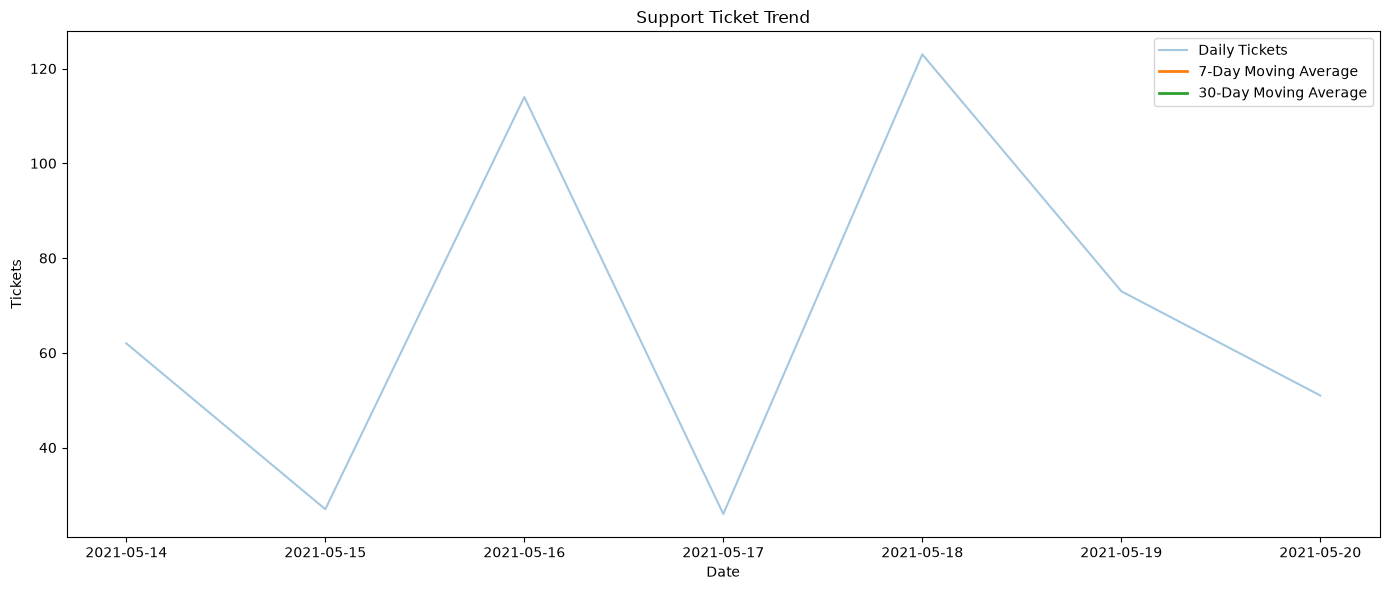


Month-over-Month Growth (%)
Date
2021-05-31   NaN
Freq: ME, Name: Tickets, dtype: float64

Growth Months
Series([], Freq: ME, Name: Tickets, dtype: float64)

Decline Months
Series([], Freq: ME, Name: Tickets, dtype: float64)


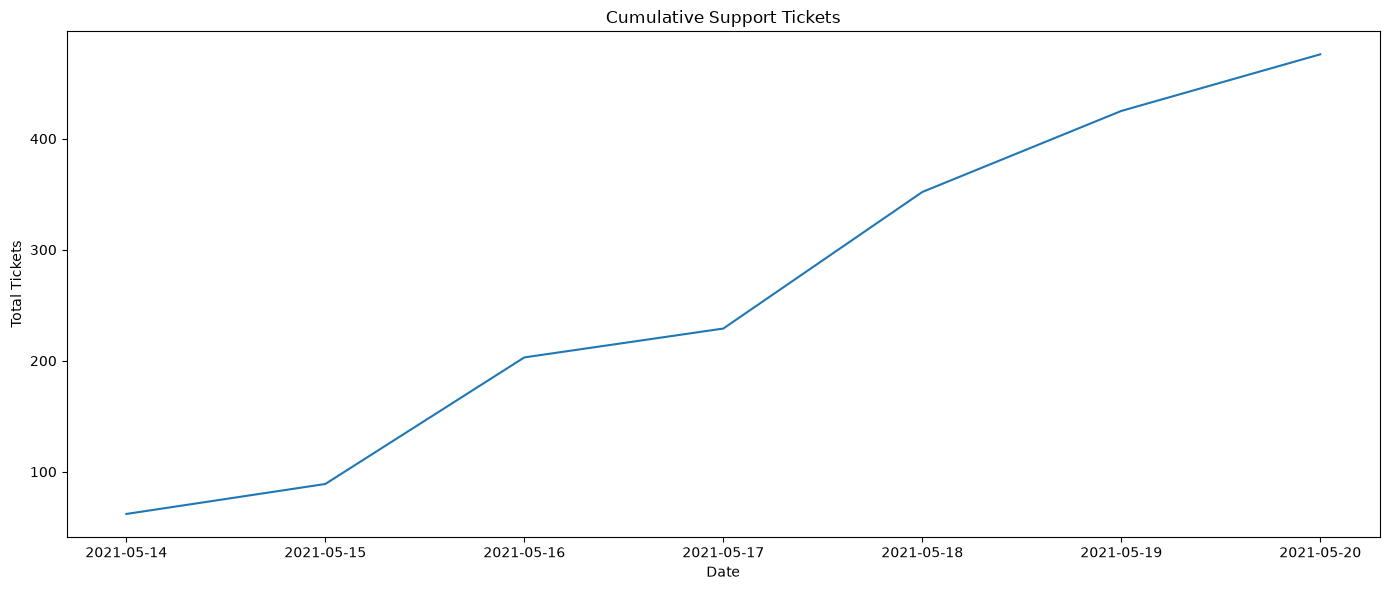


Total Tickets: 476


TIME SERIES ANALYSIS


Trend Direction : INSUFFICIENT DATA

30-Day Trend Change : 0.00 %

Latest Monthly Growth : nan %

Average Daily Tickets : 68.00

Maximum Daily Tickets : 123

Minimum Daily Tickets : 26

Ticket Volatility (Std Dev): 38.59

BUSINESS INSIGHTS


Not enough data to establish a reliable trend.


Analysis Saved Successfully
../output/rolling_avg.png
../output/cumulative_tickets.png
../output/trend_analysis.txt


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------
# Create output folder
# ---------------------------------------------------

Path("../output").mkdir(exist_ok=True)

# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------

df = pd.read_excel(
    "../data/processed/Combined_Data.xlsx",
    sheet_name="Support Tickets"
)

# ---------------------------------------------------
# Convert Date
# ---------------------------------------------------

df["Created Time (Ticket)"] = pd.to_datetime(
    df["Created Time (Ticket)"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df = df.dropna(subset=["Created Time (Ticket)"])

# ---------------------------------------------------
# Daily Ticket Count
# ---------------------------------------------------

daily = (
    df.groupby(df["Created Time (Ticket)"].dt.date)
      .size()
      .reset_index(name="Tickets")
)

daily.columns = ["Date", "Tickets"]

daily["Date"] = pd.to_datetime(daily["Date"])

daily = daily.sort_values("Date")

daily = daily.set_index("Date")

# ---------------------------------------------------
# TASK 1
# Weekly & Monthly Resampling
# ---------------------------------------------------

weekly = daily["Tickets"].resample("W").sum()

# Month End frequency (Pandas 3.x)
monthly = daily["Tickets"].resample("ME").sum()

weekly_mean = daily["Tickets"].resample("W").mean()

monthly_mean = daily["Tickets"].resample("ME").mean()

print("="*60)
print("Weekly Ticket Counts")
print("="*60)
print(weekly)

print("\nMonthly Ticket Counts")
print(monthly)

print("\nHighest Weekly Tickets")
print(weekly.idxmax(), weekly.max())

print("\nHighest Monthly Tickets")
print(monthly.idxmax(), monthly.max())

# ---------------------------------------------------
# TASK 2
# Rolling Average
# ---------------------------------------------------

daily["MA7"] = daily["Tickets"].rolling(7).mean()

daily["MA30"] = daily["Tickets"].rolling(30).mean()

plt.figure(figsize=(14,6))

plt.plot(
    daily.index,
    daily["Tickets"],
    label="Daily Tickets",
    alpha=0.4
)

plt.plot(
    daily.index,
    daily["MA7"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.plot(
    daily.index,
    daily["MA30"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("Support Ticket Trend")

plt.xlabel("Date")

plt.ylabel("Tickets")

plt.legend()

plt.tight_layout()

plt.savefig("../output/rolling_avg.png")

plt.show()

# ---------------------------------------------------
# TASK 3
# Month-over-Month Change
# ---------------------------------------------------

mom = monthly.pct_change()*100

print("\nMonth-over-Month Growth (%)")
print(mom)

growth = mom[mom>0]

decline = mom[mom<0]

print("\nGrowth Months")
print(growth)

print("\nDecline Months")
print(decline)

# ---------------------------------------------------
# TASK 4
# Cumulative Tickets
# ---------------------------------------------------

daily["Cumulative Tickets"] = daily["Tickets"].cumsum()

plt.figure(figsize=(14,6))

plt.plot(
    daily.index,
    daily["Cumulative Tickets"]
)

plt.title("Cumulative Support Tickets")

plt.xlabel("Date")

plt.ylabel("Total Tickets")

plt.tight_layout()

plt.savefig("../output/cumulative_tickets.png")

plt.show()

print("\nTotal Tickets:", daily["Cumulative Tickets"].iloc[-1])

# ---------------------------------------------------
# TASK 5
# Trend Analysis
# ---------------------------------------------------

recent = daily["MA30"].dropna()

if len(recent) > 1:

    start = recent.iloc[0]

    end = recent.iloc[-1]

    direction = "UPWARD" if end > start else "DOWNWARD"

    change = ((end-start)/start)*100 if start != 0 else 0

else:

    direction = "INSUFFICIENT DATA"

    change = 0

analysis = f"""
================================================

TIME SERIES ANALYSIS

================================================

Trend Direction : {direction}

30-Day Trend Change : {change:.2f} %

Latest Monthly Growth : {mom.iloc[-1]:.2f} %

Average Daily Tickets : {daily['Tickets'].mean():.2f}

Maximum Daily Tickets : {daily['Tickets'].max()}

Minimum Daily Tickets : {daily['Tickets'].min()}

Ticket Volatility (Std Dev): {daily['Tickets'].std():.2f}

BUSINESS INSIGHTS

"""

if direction=="UPWARD":

    analysis += """
Support workload is increasing.

Recommendation:
Increase staffing.
Monitor response SLA.
Investigate recurring ticket categories.
"""

elif direction=="DOWNWARD":

    analysis += """
Support workload is decreasing.

Recommendation:
Review customer satisfaction.
Investigate whether product quality has improved.
Maintain staffing efficiency.
"""

else:

    analysis += """
Not enough data to establish a reliable trend.
"""

print(analysis)

with open(
    "../output/trend_analysis.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(analysis)

print("\nAnalysis Saved Successfully")

print("../output/rolling_avg.png")
print("../output/cumulative_tickets.png")
print("../output/trend_analysis.txt")